<a href="https://colab.research.google.com/github/lohithharish798-creator/capstone-project-part-1/blob/main/capstone_part_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
#1 load data
df = pd.read_csv("/content/fifa_world_cup_2026_player_performance.csv")
print("first five rows:\n",df.head())
print("\ncolumn data types:\n",df.dtypes)
print("/ndataframe shape:",df.shape)

first five rows:
   player_id       player_name  age nationality   team  jersey_number  \
0    P00055        Rodri Fati   26     Spanish  Spain              3   
1    P00070   Ansu Le Normand   19     Spanish  Spain             18   
2    P00066        Gavi Ramos   18     Spanish  Spain             14   
3    P00073     Pedro Cubarsi   20     Spanish  Spain             21   
4    P00059  Alvaro Oyarzabal   23     Spanish  Spain              7   

     position  height_cm  weight_kg preferred_foot  ... possession_impact  \
0  Goalkeeper        195         75           Left  ...               1.1   
1  Midfielder        178         75          Right  ...               3.5   
2  Midfielder        177         72           Left  ...              15.3   
3     Forward        182         74          Right  ...               1.2   
4    Defender        191         81           Left  ...               6.2   

   pressure_resistance creativity_score consistency_score  \
0                 44.2   

In [ ]:
# 2. null value analysis
null_counts = df.isna().sum()
null_percentage = (null_counts / len(df)) * 100
print("\nnull value counts:\n",null_counts)
print("\nnull value percentage:\n",null_percentage)
#identify col> 20%
cols_above_20 = null_percentage[null_percentage > 20].index
print("\ncolumns with more than 20% null values:\n",cols_above_20)
#fill columns < 20% with medium
for col in cols_above_20:
  df[col].fillna(df[col].median(),inplace=True)


null value counts:
 player_id                   0
player_name                 0
age                         0
nationality                 0
team                        0
                           ..
total_goals_tournament      1
total_assists_tournament    1
total_minutes_tournament    1
player_of_match_awards      1
tournament_rating           1
Length: 75, dtype: int64

null value percentage:
 player_id                   0.00000
player_name                 0.00000
age                         0.00000
nationality                 0.00000
team                        0.00000
                             ...   
total_goals_tournament      0.00429
total_assists_tournament    0.00429
total_minutes_tournament    0.00429
player_of_match_awards      0.00429
tournament_rating           0.00429
Length: 75, dtype: float64

columns with more than 20% null values:
 Index([], dtype='object')


In [ ]:
# part 3 duplicates detection
duplicates_count = df.duplicated().sum()
df = df.drop_duplicates()
print(f"duplicates removed: {duplicates_count}")
print("new null percentages:\n",(df.isna().sum()/len(df))*100)

duplicates removed: 0
new null percentages:
 player_id                   0.00000
player_name                 0.00000
age                         0.00000
nationality                 0.00000
team                        0.00000
                             ...   
total_goals_tournament      0.00429
total_assists_tournament    0.00429
total_minutes_tournament    0.00429
player_of_match_awards      0.00429
tournament_rating           0.00429
Length: 75, dtype: float64


In [ ]:
# part 4 data type correction
print("memory usage before:", df.memory_usage(deep=True).sum())
print("memory usage after:",df.memory_usage(deep=True).sum())

memory usage before: 30113615
memory usage after: 30113615


In [ ]:
#part 5 statistics and skewness
print(df.describe())
skeness=df.select_dtypes(include='number').skew()
highest_skew_col = skeness.abs().idxmax()
print(f"highest absolute skewness:{highest_skew_col}({skeness[highest_skew_col]})")
#


               age  jersey_number     height_cm     weight_kg  \
count  23310.00000   23310.000000  23310.000000  23310.000000   
mean      26.30266      13.500257    181.645560     75.775204   
std        4.06437       7.500287      6.274553      3.947737   
min       17.00000       1.000000    163.000000     65.000000   
25%       23.00000       7.000000    177.000000     73.000000   
50%       26.00000      13.500000    182.000000     76.000000   
75%       29.00000      20.000000    186.000000     78.000000   
max       39.00000      26.000000    200.000000     87.000000   

       market_value_eur    goals_team  goals_opponent  minutes_played  \
count      2.331000e+04  23310.000000    23310.000000    23310.000000   
mean       2.014592e+07      1.323552        1.322952       36.147662   
std        2.702225e+07      1.127311        1.126684       36.448936   
min        5.288220e+05      0.000000        0.000000        0.000000   
25%        4.469531e+06      1.000000        1.00

In [ ]:
#part 6 outlier detection iqr
def count_outliers(column):
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
  return len(outliers)


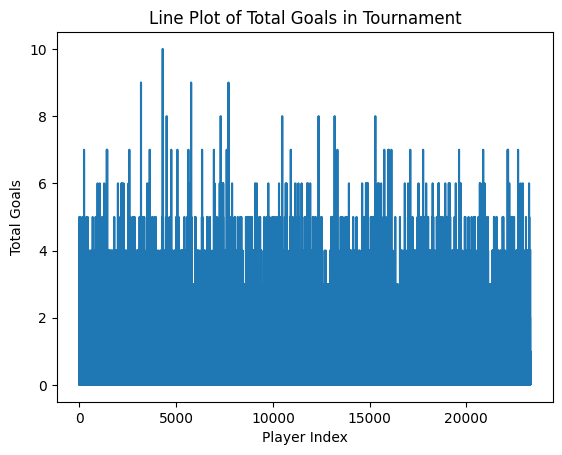

In [ ]:
#part 7 visualizatins
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure()
df['total_goals_tournament'].plot(kind='line')
plt.title('Line Plot of Total Goals in Tournament')
plt.xlabel('Player Index')
plt.ylabel('Total Goals')
plt.show()

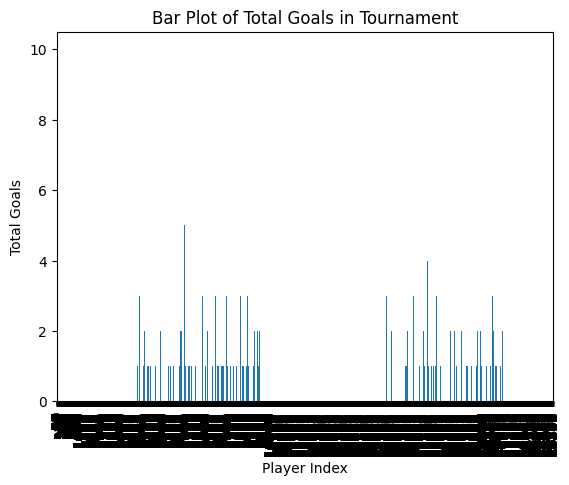

In [ ]:
#part 7 b.bar chart
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure()
df['total_goals_tournament'].plot(kind='bar')
plt.title('Bar Plot of Total Goals in Tournament')
plt.xlabel('Player Index')
plt.ylabel('Total Goals')
plt.show()

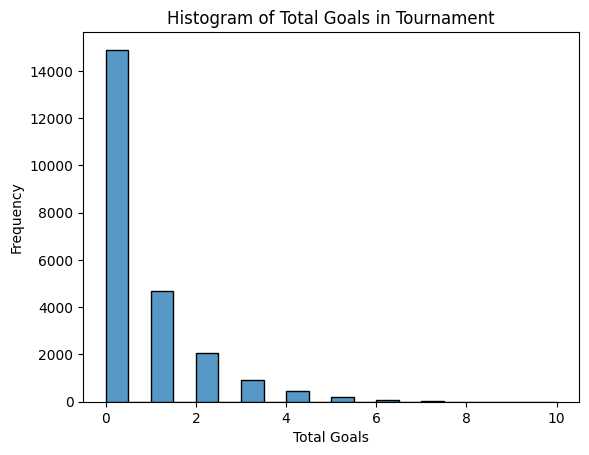

In [ ]:
#part 7 c histogram
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure()
sns.histplot(df['total_goals_tournament'],bins=20)
plt.title('Histogram of Total Goals in Tournament')
plt.xlabel('Total Goals')
plt.ylabel('Frequency')
plt.show()
#

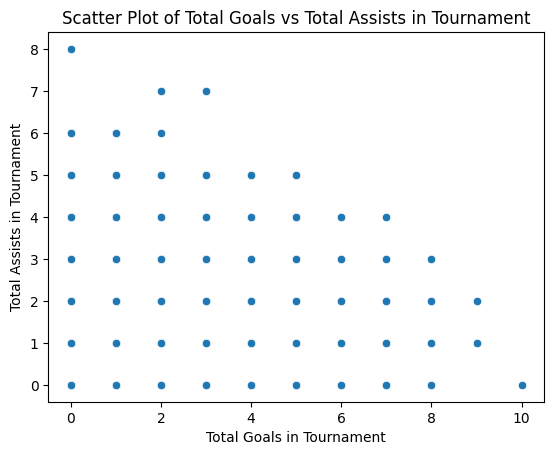

In [ ]:
# part 7 d scatter plot
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure()
sns.scatterplot(x='total_goals_tournament', y='total_assists_tournament', data=df)
plt.title('Scatter Plot of Total Goals vs Total Assists in Tournament')
plt.xlabel('Total Goals in Tournament')
plt.ylabel('Total Assists in Tournament')
plt.show()

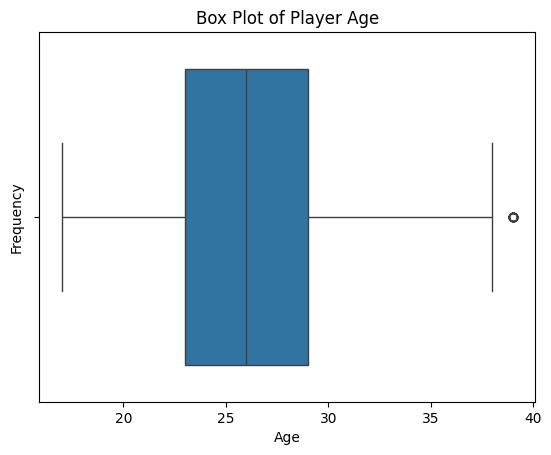

In [ ]:
# part 7  5 box plot
plt.figure()
sns.boxplot(x='age', data=df)
plt.title('Box Plot of Player Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

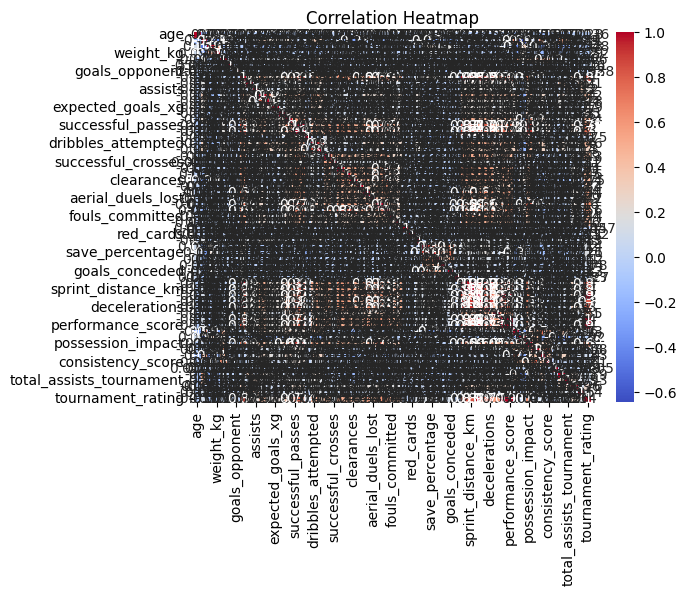

                               age  jersey_number  height_cm  weight_kg  \
age                       1.000000      -0.193311   0.120207   0.094330   
jersey_number            -0.193311       1.000000  -0.483986  -0.320138   
height_cm                 0.120207      -0.483986   1.000000   0.633028   
weight_kg                 0.094330      -0.320138   0.633028   1.000000   
market_value_eur         -0.070958       0.183552  -0.103798  -0.068547   
...                            ...            ...        ...        ...   
total_goals_tournament   -0.102006       0.529394  -0.244833  -0.166655   
total_assists_tournament -0.101360       0.364517  -0.223050  -0.126995   
total_minutes_tournament -0.010174       0.009880  -0.005361   0.005214   
player_of_match_awards   -0.027837       0.089486  -0.042666  -0.028917   
tournament_rating        -0.035528       0.108877  -0.078067  -0.052103   

                          market_value_eur  goals_team  goals_opponent  \
age                      

In [ ]:
# part 8 correlation
# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()
print(correlation_matrix)

In [ ]:
# part 9 imputation strategy
cols_to_impute = df.columns[df.isnull().any()]
for col in cols_to_impute:
  mean_val = df[col].mean()
  median_val = df[col].median()
  print(f"column:{col} | mean:{mean_val:.2f} | median:{median_val:.2f}")
  df[col].fillna(median_val,inplace=True)
  print(df[col].isnull().sum())
#
#

column:creativity_score | mean:46.16 | median:40.50
0
column:consistency_score | mean:63.78 | median:61.10
0
column:clutch_performance_score | mean:55.07 | median:55.10
0
column:total_goals_tournament | mean:0.64 | median:0.00
0
column:total_assists_tournament | mean:0.61 | median:0.00
0
column:total_minutes_tournament | mean:272.27 | median:267.00
0
column:player_of_match_awards | mean:0.03 | median:0.00
0
column:tournament_rating | mean:3.63 | median:5.40
0


/tmp/ipykernel_830/2215618606.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val,inplace=True)


Spearman Correlation:
                                age  jersey_number  height_cm  weight_kg  \
age                       1.000000      -0.182329   0.130019   0.094136   
jersey_number            -0.182329       1.000000  -0.469529  -0.312005   
height_cm                 0.130019      -0.469529   1.000000   0.628956   
weight_kg                 0.094136      -0.312005   0.628956   1.000000   
market_value_eur         -0.100610       0.241066  -0.102706  -0.076051   
...                            ...            ...        ...        ...   
total_goals_tournament   -0.108070       0.573738  -0.269167  -0.178445   
total_assists_tournament -0.105521       0.404367  -0.246497  -0.144626   
total_minutes_tournament -0.008060       0.009143  -0.004071   0.006914   
player_of_match_awards   -0.030191       0.099936  -0.041643  -0.029400   
tournament_rating        -0.032685       0.110158  -0.073837  -0.053415   

                          market_value_eur  goals_team  goals_opponent  \
ag

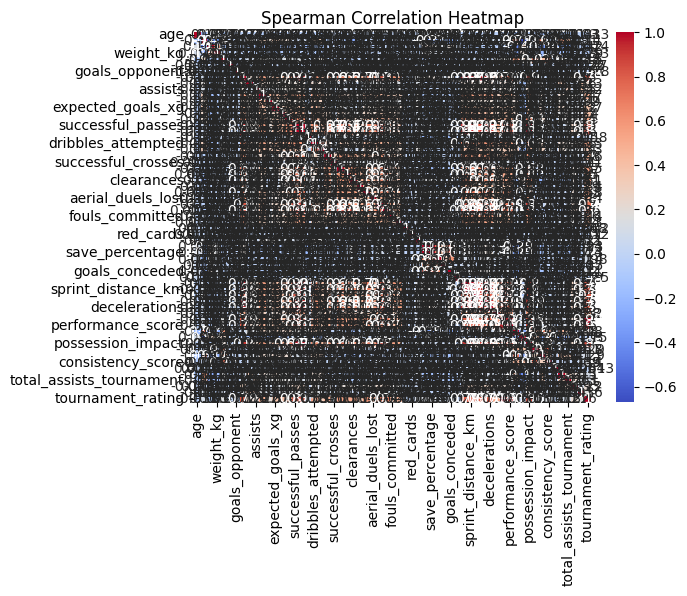

In [ ]:
# part 9 b spearman rank
numeric_df = df.select_dtypes(include=['number'])
spearman_corr = numeric_df.corr(method='spearman')
pearsons_corr = numeric_df.corr(method='pearson')
print("Spearman Correlation:\n", spearman_corr)
print("\nPearson Correlation:\n", pearsons_corr)
sns.heatmap(spearman_corr,annot=True,cmap='coolwarm')
plt.title('Spearman Correlation Heatmap')
plt.show()

In [ ]:
# part 9 c grouped
# Group by 'team' and calculate the mean of 'total_goals_tournament'
grouped = df.groupby('team')['total_goals_tournament'].mean()
print("Mean total goals per team:\n", grouped)

# Find the team with the highest mean total goals
highest_mean_goals_team = grouped.idxmax()
print(f"\nTeam with the highest mean total goals: {highest_mean_goals_team} ({grouped.max():.2f} goals)")

Mean total goals per team:
 team
Algeria          0.722222
Argentina        0.582418
Australia        0.607287
Austria          0.653846
Belgium          0.645833
Brazil           0.639676
Cameroon         0.638112
Canada           0.625418
Chile            0.556410
Colombia         0.625506
Costa Rica       0.681818
Croatia          0.664530
Denmark          0.656109
Ecuador          0.636752
Egypt            0.634615
England          0.532178
France           0.615385
Germany          0.668639
Ghana            0.631868
Iran             0.650888
Iraq             0.674089
Italy            0.652473
Jamaica          0.649867
Japan            0.653846
Mexico           0.617521
Morocco          0.692308
Netherlands      0.621795
Nigeria          0.608597
Panama           0.645749
Peru             0.645749
Poland           0.622596
Portugal         0.757085
Qatar            0.652174
Saudi Arabia     0.662393
Scotland         0.629371
Senegal          0.671329
Serbia           0.569231
South

In [ ]:
df.to_csv('clened_data.csv',index=False)